# Importación de librerías

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# Carga de archivos (.txt) y etiquetado

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# --- CONFIGURACIÓN DE RUTAS ---
bueno_dir = '/content/drive/MyDrive/Colab Notebooks/BUENO'
malo_dir = '/content/drive/MyDrive/Colab Notebooks/MALO'

X_features = []
y_labels = []

def cargar_sustancias(ruta_carpeta, etiqueta):
    conteo = 0
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".txt"):
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            try:
                # Usamos pandas.read_csv, que es más robusto para archivos con decimales ','
                # y permite saltar filas con 'skiprows'. Cambiamos 'sep' a espacio.
                datos_df = pd.read_csv(ruta_completa, sep=' ', decimal=',', skiprows=1, header=None)

                # Convertir todas las columnas a numérico, forzando los errores a NaN
                datos_df = datos_df.apply(pd.to_numeric, errors='coerce')

                # Convertir a numpy y aplanar
                datos = datos_df.values.flatten()

                # DEBUG: Imprimir información sobre el archivo y si está todo NaN
                if np.all(np.isnan(datos)):
                    print(f"Advertencia: Archivo '{archivo}' de la carpeta '{os.path.basename(ruta_carpeta)}' contiene solo NaNs después del procesamiento y será ignorado.")
                else:
                    X_features.append(datos)
                    y_labels.append(etiqueta)
                    conteo += 1
            except Exception as e:
                print(f"Error en {archivo} de la carpeta '{os.path.basename(ruta_carpeta)}': {e}")
    return conteo

# Cargar datos
n_buenos = cargar_sustancias(bueno_dir, 1) # 1 para Sustancia Correcta
n_malos = cargar_sustancias(malo_dir, 0)   # 0 para Otras Sustancias

# --- MODIFICACIÓN PARA MANEJAR LARGOS VARIABLES Y RELLENAR ---
# Solo procesar si X_features no está vacío
if X_features:
    # Encontrar la longitud máxima entre todos los arrays cargados
    max_len = max(len(x) for x in X_features)

    # Rellenar (pad) los arrays más cortos con NaN para que todos tengan la misma longitud
    padded_X_features = []
    for x in X_features:
        if len(x) < max_len:
            # Crear un array de NaN para rellenar
            padding = np.full(max_len - len(x), np.nan)
            padded_X_features.append(np.concatenate((x, padding)))
        else:
            padded_X_features.append(x)
    X = np.array(padded_X_features)
else:
    X = np.array([]) # Si no hay datos, X será un array vacío
    print("Advertencia: No se cargaron datos en X_features.")

y = np.array(y_labels)

print(f"Finalizado: {n_buenos} archivos BUENOS y {n_malos} archivos MALOS cargados.")
print(f"Forma de la matriz X: {X.shape}")

Finalizado: 22 archivos BUENOS y 20 archivos MALOS cargados.
Forma de la matriz X: (42, 242676)


# División del Dataset (Train, Val, Test) y Escalado

In [12]:
# Dividir el dataset en entrenamiento+validación y prueba
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Dividir el conjunto de entrenamiento+validación en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
) # 0.25 de 0.8 es 0.2 del total

# Imputación y Escalado
imputer = SimpleImputer(strategy='constant', fill_value=0)
scaler = StandardScaler()

# Aplicar imputación y escalado
X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_val = scaler.transform(imputer.transform(X_val))
X_test = scaler.transform(imputer.transform(X_test))

# Convertir a Tensores de PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Crear DataLoader para el entrenamiento y validación
batch_size=3
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

print(f"Datos listos.")
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Validación: {X_val.shape[0]} muestras")
print(f"Prueba final (Test): {X_test.shape[0]} muestras")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


Datos listos.
Entrenamiento: 24 muestras
Validación: 9 muestras
Prueba final (Test): 9 muestras


# Definición y Entrenamiento de la ANN

In [13]:
# Definición de la Red Neuronal (Arquitectura idéntica a la original)
class OlfativaANN(nn.Module):
    def __init__(self, input_dim):
        super(OlfativaANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Inicializar modelo, función de pérdida y optimizador
input_features = X_train.shape[1]
model = OlfativaANN(input_features)
criterion = nn.BCELoss() # Entropía Cruzada Binaria
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Bucle de Entrenamiento
epochs = 50
print("Iniciando entrenamiento...")

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Parámetros para Early Stopping
early_stopping_patience = 10 # Número de épocas a esperar si no hay mejora
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # Evaluación en el conjunto de validación
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            predicted = (outputs > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)

    # Lógica de Early Stopping
    current_val_loss = val_losses[-1]
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        patience_counter = 0
        # Opcional: Guardar el mejor modelo aquí
        # torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping en la época {epoch+1}. La pérdida de validación no mejoró por {early_stopping_patience} épocas.")
            break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Acc: {train_accuracies[-1]:.2f}%, Val Acc: {val_accuracies[-1]:.2f}%, Train Loss: {train_losses[-1]:.4f},  Val Loss: {val_losses[-1]:.4f}")

Iniciando entrenamiento...
Epoch [10/50], Train Acc: 75.00%, Val Acc: 55.56%, Train Loss: 0.4610,  Val Loss: 0.7464
Epoch [20/50], Train Acc: 83.33%, Val Acc: 66.67%, Train Loss: 0.3056,  Val Loss: 0.6437
Epoch [30/50], Train Acc: 79.17%, Val Acc: 66.67%, Train Loss: 0.4304,  Val Loss: 0.4705
Epoch [40/50], Train Acc: 83.33%, Val Acc: 66.67%, Train Loss: 0.3251,  Val Loss: 0.9094
Early stopping en la época 47. La pérdida de validación no mejoró por 10 épocas.


# Evaluación y Resultados

In [14]:
# Evaluación Final
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_classes = (predictions > 0.5).float()
    accuracy = (predicted_classes == y_test_tensor).float().mean()
    print(f"\n--- RESULTADOS FINALES ---")
    print(f"Precisión en Test: {accuracy.item()*100:.2f}%")


--- RESULTADOS FINALES ---
Precisión en Test: 88.89%


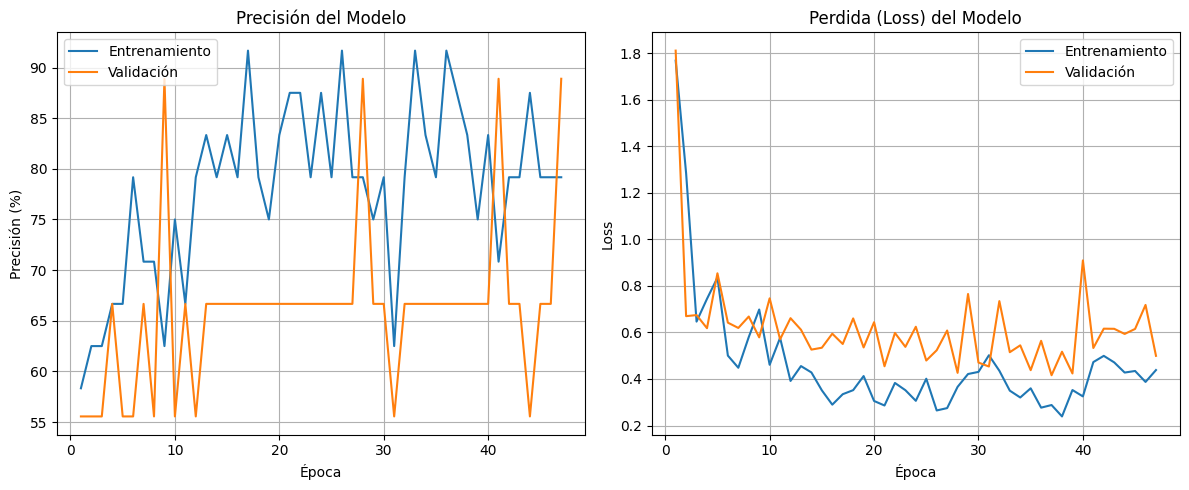

In [15]:
# Ajustar epochs_range al número real de épocas entrenadas
epochs_range = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(12, 5))

# Graficar la Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracies, label='Entrenamiento')
plt.plot(epochs_range, val_accuracies, label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión (%)')
plt.legend()
plt.grid(True)

# Graficar la Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label='Entrenamiento')
plt.plot(epochs_range, val_losses, label='Validación')
plt.title('Perdida (Loss) del Modelo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

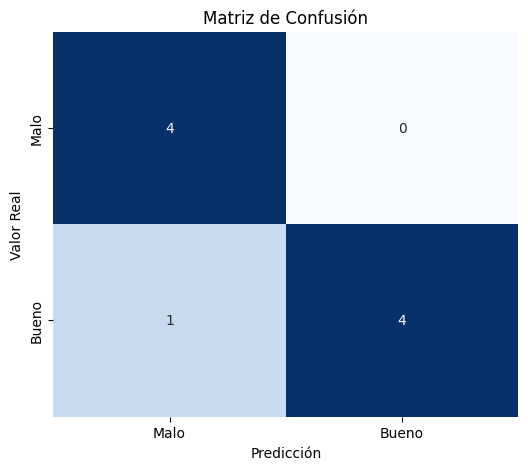

In [16]:

# Obtener las predicciones del modelo en el conjunto de prueba
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_classes = (predictions > 0.5).float().cpu().numpy() # Convertir a numpy
    true_classes = y_test_tensor.cpu().numpy() # Convertir a numpy

# Calcular la matriz de confusión
cm = confusion_matrix(true_classes, predicted_classes)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malo', 'Bueno'], yticklabels=['Malo', 'Bueno'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Guardar el modelo

In [17]:
# Definir la ruta para guardar el modelo
model_save_path = '/content/drive/MyDrive/Colab Notebooks/modelo_nariz_pytorch.pth'

# Guardar el diccionario de estado del modelo
torch.save(model.state_dict(), model_save_path)

print(f"Modelo guardado exitosamente en: {model_save_path}")

Modelo guardado exitosamente en: /content/drive/MyDrive/Colab Notebooks/modelo_nariz_pytorch.pth
